# MNIST Latent Rectified-Flow MM-DiT

Train a rectified-flow generative model in the latent space of a small convolutional autoencoder, using an SD3-style **MM-DiT** (dual-stream diffusion transformer) as the velocity network.

Pipeline: **load pretrained AE → precompute latents → train MM-DiT → sample class-conditional digits**.

- MNIST digits are resized to 32×32; the AE (trained in `projects/mnist/autoencoder`) encodes each to a spatial `(latent_channels, 4, 4)` latent.
- Latents are precomputed once and standardized (per-channel zero-mean/unit-var), then cached.
- The MM-DiT has two token streams — image-latent patches and class-label tokens — with joint attention and adaLN-Zero timestep conditioning.
- Rectified flow: predict velocity `v = data - noise` along `z_t = (1-t)·noise + t·data`; sample with an Euler ODE + classifier-free guidance.

In [15]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os

import matplotlib.pyplot as plt
import pandas as pd
import torch
from lightning import Trainer, seed_everything
from torchinfo import summary

from chimera.optim import LinearWarmupCosineAnnealingLR

os.environ["DATA_DIR"] = "../../../data"
DATA_DIR = os.environ["DATA_DIR"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_float32_matmul_precision("high")

# Reproducibility: seed all RNGs (incl. dataloader workers). Pair with
# Trainer(deterministic=True) below for deterministic CUDA kernels too.
SEED = 42
seed_everything(SEED, workers=True)
DEVICE

Seed set to 42


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'cuda'

## Stage 1 — Autoencoder (spatial latent)

Load the small conv AE (`DigitDreamerAE`) trained in **`projects/mnist/autoencoder`** — run that notebook first so its `checkpoints/ae.ckpt` exists. Its `1x1`-conv bottleneck gives a `(B, latent_channels, 4, 4)` spatial latent for a 32×32 input (instead of a flat vector), which the MM-DiT then patchifies into tokens.

In [16]:
from chimera.data import MNISTDataModule

dm = MNISTDataModule(data_dir=DATA_DIR, batch_size=128, num_workers=4, image_size=32)
dm.prepare_data()
dm.setup("fit")
ae_train_loader = dm.train_dataloader()
ae_val_loader = dm.val_dataloader()

In [17]:
from chimera.models import DigitDreamerAE

LATENT_CHANNELS = 1
ae = DigitDreamerAE(in_channels=1, latent_dim=LATENT_CHANNELS)
summary(
    ae, input_size=(1, 1, 32, 32), col_names=["output_size", "num_params"], verbose=0
)

Layer (type:depth-idx)                   Output Shape              Param #
DigitDreamerAE                           [1, 1, 32, 32]            --
├─Conv2d: 1-1                            [1, 16, 32, 32]           160
├─Sequential: 1-2                        [1, 64, 4, 4]             --
│    └─ResBlock: 2-1                     [1, 16, 32, 32]           --
│    │    └─Conv2d: 3-1                  [1, 16, 32, 32]           2,320
│    │    └─BatchNorm2d: 3-2             [1, 16, 32, 32]           32
│    │    └─GELU: 3-3                    [1, 16, 32, 32]           --
│    │    └─Conv2d: 3-4                  [1, 16, 32, 32]           2,320
│    │    └─BatchNorm2d: 3-5             [1, 16, 32, 32]           32
│    │    └─Identity: 3-6                [1, 16, 32, 32]           --
│    │    └─GELU: 3-7                    [1, 16, 32, 32]           --
│    └─DCDownBlock: 2-2                  [1, 32, 16, 16]           --
│    │    └─Conv2d: 3-8                  [1, 32, 16, 16]           18,464
│   

In [26]:
# Load the autoencoder trained in projects/mnist/autoencoder instead of retraining
# one here. Run that notebook first so ../autoencoder/checkpoints/ae.ckpt exists.
AE_CKPT = "../autoencoder/checkpoints/ae.ckpt"

ckpt = torch.load(AE_CKPT, map_location="cpu")
# The checkpoint holds an AutoencoderModule; its weights are under the "model." prefix.
ae_state = {
    k.removeprefix("model."): v
    for k, v in ckpt["state_dict"].items()
    if k.startswith("model.")
}
ae.load_state_dict(ae_state)
ae.to(DEVICE).eval()
print(f"loaded AE from {AE_CKPT} ({sum(p.numel() for p in ae.parameters()):,} params)")

loaded AE from ../autoencoder/checkpoints/ae.ckpt (870,306 params)


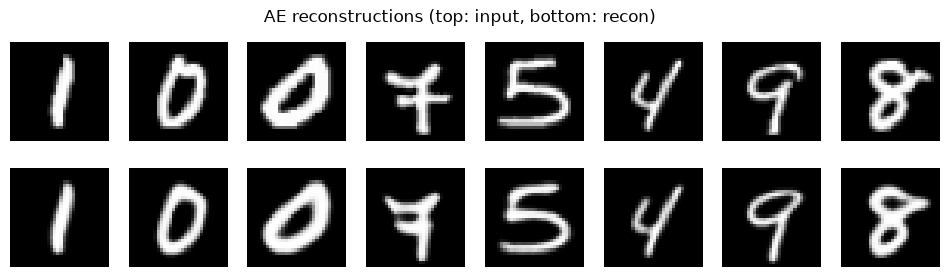

In [27]:
ae.to(DEVICE, dtype=torch.bfloat16).eval()
x, _ = next(iter(ae_val_loader))
x = x[:8].to(DEVICE, dtype=torch.bfloat16)
with torch.no_grad():
    recon = ae(x)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(x[i, 0].cpu().float(), cmap="gray")
    axes[1, i].imshow(recon[i, 0].cpu().float(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].axis("off")
plt.suptitle("AE reconstructions (top: input, bottom: recon)")
plt.show()

## Stage 2 — Precompute latents

Encode all of MNIST with the trained AE once, standardize per channel, and cache to a `.pt`. `MNISTLatentDataModule` then serves `(latent, label)` pairs; re-running `setup()` loads the cache instantly.

In [28]:
from chimera.data import MNISTLatentDataModule

latent_dm = MNISTLatentDataModule(
    autoencoder=ae,
    data_dir=DATA_DIR,
    batch_size=256,
    num_workers=4,
    device=DEVICE,
    image_size=32,
)
latent_dm.prepare_data()  # encodes MNIST -> standardized latents, cached to .pt
latent_dm.setup("fit")
rf_train_loader = latent_dm.train_dataloader()
rf_val_loader = latent_dm.val_dataloader()

zb, yb = next(iter(rf_train_loader))
print("latent batch:", tuple(zb.shape), "labels:", tuple(yb.shape))
print("cache:", latent_dm.cache_path)
print(f"standardized mean~0 / std~1: {zb.mean().item():.3f} / {zb.std().item():.3f}")

latent batch: (256, 1, 4, 4) labels: (256,)
cache: ../../../data/mnist_latents/latents_c1_s32_seed42.pt
standardized mean~0 / std~1: -0.007 / 0.988


## Stage 3 — Train MM-DiT (rectified flow)

The MM-DiT predicts the rectified-flow velocity. Timesteps are sampled logit-normally (SD3), the label is randomly dropped to a null class (10% of the time) so the model also learns the unconditional velocity for classifier-free guidance.

In [29]:
from chimera.models import MMDiT

mmdit = MMDiT(
    latent_channels=LATENT_CHANNELS,
    latent_size=4,
    patch_size=1,
    dim=64,
    depth=4,
    n_head=1,
    n_classes=10,
    n_cond_tokens=4,
    class_dropout_prob=0.1,
)
n_params = sum(p.numel() for p in mmdit.parameters())
print(f"MM-DiT parameters: {n_params / 1e6:.2f}M")

MM-DiT parameters: 0.63M


In [30]:
from chimera.modules import RectifiedFlowModule

RF_EPOCHS = 5
rf_opt = torch.optim.AdamW(
    mmdit.parameters(), lr=1e-3, betas=(0.9, 0.95), weight_decay=0.1
)
rf_sched = LinearWarmupCosineAnnealingLR(
    rf_opt, warmup_steps=500, n_epochs=RF_EPOCHS, train_loader=rf_train_loader
)

mmdit_compiled = torch.compile(mmdit)
rf_module = RectifiedFlowModule(mmdit_compiled, rf_opt, rf_sched)

rf_trainer = Trainer(
    max_epochs=RF_EPOCHS,
    precision="bf16-mixed",
    gradient_clip_val=1.0,
    deterministic=True,
)
rf_trainer.fit(rf_module, rf_train_loader, rf_val_loader)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/root/Code/chimera/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type            | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | model     | Optimize

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/root/Code/chimera/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


## Stage 4 — Sample & visualize

Generate latents for each digit class with classifier-free guidance, un-standardize, and decode back to images. Recognizable digits matching the requested class are the end-to-end proof that the AE + latents + MM-DiT + rectified flow all work together.

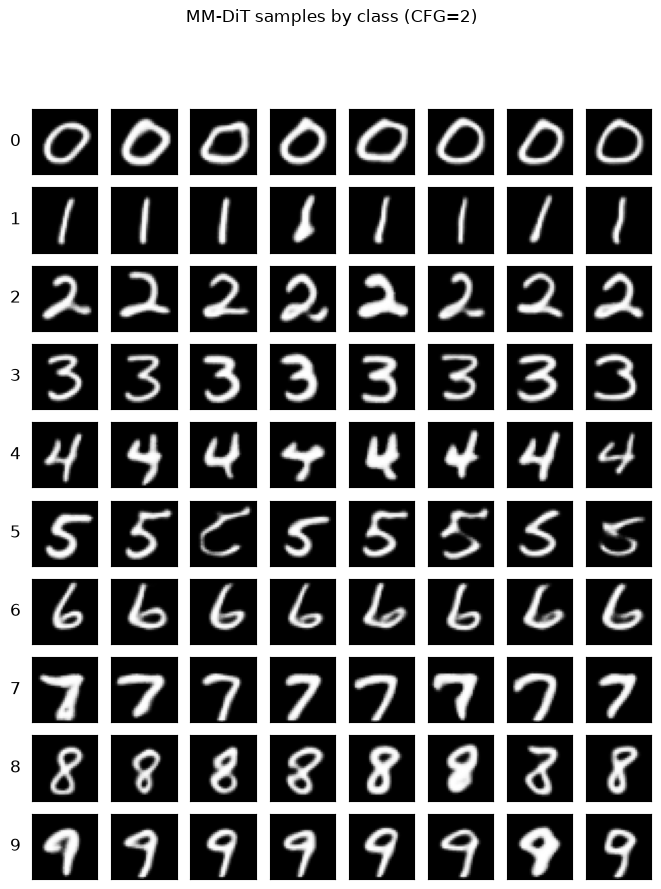

In [37]:
# Lightning leaves the model on CPU after fit; move to GPU + float32 for sampling.
mmdit.to(DEVICE).float().eval()
ae.to(DEVICE).float().eval()

mean = latent_dm.latent_mean.to(DEVICE)
std = latent_dm.latent_std.to(DEVICE)

N_PER_CLASS = 8
CFG_SCALE = 2
labels = torch.arange(10).repeat_interleave(N_PER_CLASS)

# Sample through the raw (uncompiled) module.
sampler = RectifiedFlowModule(mmdit, rf_opt, rf_sched)
with torch.inference_mode():
    z = sampler.sample(labels, n_steps=50, cfg_scale=CFG_SCALE)
    z = z * std + mean
    imgs = ae.decode(z)

fig, axes = plt.subplots(10, N_PER_CLASS, figsize=(N_PER_CLASS, 10))
for r in range(10):
    for c in range(N_PER_CLASS):
        ax = axes[r, c]
        ax.imshow(imgs[r * N_PER_CLASS + c, 0].cpu(), cmap="gray")
        ax.set_xticks([])
        ax.set_yticks([])
    axes[r, 0].set_ylabel(str(r), rotation=0, labelpad=12, fontsize=12, va="center")
plt.suptitle(f"MM-DiT samples by class (CFG={CFG_SCALE})")
plt.show()

In [ ]:
m = pd.read_csv(f"{rf_trainer.logger.log_dir}/metrics.csv")
plt.figure(figsize=(6, 4))
for col in ["train/loss_step", "val/loss", "val/loss_epoch"]:
    if col in m.columns:
        d = m.dropna(subset=[col])
        plt.plot(
            d["step"],
            d[col],
            marker=None if col == "train/loss_step" else "o",
            label=col,
        )
plt.xlabel("step")
plt.ylabel("velocity L1")
plt.legend()
plt.title("MM-DiT rectified-flow loss")
plt.show()